In [16]:
import os
import shutil
import random

random.seed(42)

# Source folders
images_src = "../data/images"
labels_src = "../data/labels"

# Target folders
train_img_dir = "../data/images/train"
val_img_dir = "../data/images/val"
test_img_dir = "../data/images/test"

train_lbl_dir = "../data/labels/train"
val_lbl_dir = "../data/labels/val"
test_lbl_dir = "../data/labels/test"

# Create target folders
for folder in [train_img_dir, val_img_dir, test_img_dir, train_lbl_dir, val_lbl_dir, test_lbl_dir]:
    os.makedirs(folder, exist_ok=True)

# Get only images that have matching label files
image_files = [f for f in os.listdir(images_src) if f.endswith(".jpg")]
valid_pairs = []

for img_file in image_files:
    image_id = os.path.splitext(img_file)[0]
    label_file = f"{image_id}.txt"
    label_path = os.path.join(labels_src, label_file)

    if os.path.exists(label_path):
        valid_pairs.append((img_file, label_file))

print("Total valid image-label pairs:", len(valid_pairs))

# Shuffle and split
random.shuffle(valid_pairs)

total = len(valid_pairs)
train_end = int(0.7 * total)
val_end = int(0.9 * total)

train_pairs = valid_pairs[:train_end]
val_pairs = valid_pairs[train_end:val_end]
test_pairs = valid_pairs[val_end:]

print(f"Train: {len(train_pairs)}")
print(f"Val: {len(val_pairs)}")
print(f"Test: {len(test_pairs)}")

# Copy files
def copy_pairs(pairs, img_dest, lbl_dest):
    for img_file, lbl_file in pairs:
        shutil.copy(os.path.join(images_src, img_file), os.path.join(img_dest, img_file))
        shutil.copy(os.path.join(labels_src, lbl_file), os.path.join(lbl_dest, lbl_file))

copy_pairs(train_pairs, train_img_dir, train_lbl_dir)
copy_pairs(val_pairs, val_img_dir, val_lbl_dir)
copy_pairs(test_pairs, test_img_dir, test_lbl_dir)

print("\nDataset split completed.")

Total valid image-label pairs: 5626
Train: 3938
Val: 1125
Test: 563

Dataset split completed.


In [17]:
import os

print("Train images:", len(os.listdir("../data/images/train")))
print("Val images:", len(os.listdir("../data/images/val")))
print("Test images:", len(os.listdir("../data/images/test")))

print("Train labels:", len(os.listdir("../data/labels/train")))
print("Val labels:", len(os.listdir("../data/labels/val")))
print("Test labels:", len(os.listdir("../data/labels/test")))

Train images: 3938
Val images: 1125
Test images: 563
Train labels: 3938
Val labels: 1125
Test labels: 563


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="../data/data.yaml",
    epochs=20,
    imgsz=640,
    batch=8,
    project="../outputs/model",
    name="vehicle_detector"
)

New https://pypi.org/project/ultralytics/8.4.36 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.30  Python-3.13.12 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-1235U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_detector, nbs=64

In [ ]:
import os

weights_dir = "../outputs/model/vehicle_detector/weights"
print("Weights folder exists:", os.path.exists(weights_dir))

if os.path.exists(weights_dir):
    print("Files:", os.listdir(weights_dir)).
    

Weights folder exists: False


In [3]:
import os

model_root = "../outputs/model"

print("Model root exists:", os.path.exists(model_root))
if os.path.exists(model_root):
    print("Contents of model root:")
    print(os.listdir(model_root))

Model root exists: True
Contents of model root:
[]


In [4]:
import os

pt_files = []

for root, dirs, files in os.walk(".."):
    for file in files:
        if file.endswith(".pt"):
            pt_files.append(os.path.join(root, file))

print("Found .pt files:")
for f in pt_files:
    print(f)

Found .pt files:
..\notebooks\yolov8n.pt
..\notebooks\runs\outputs\model\vehicle_detector\weights\best.pt
..\notebooks\runs\outputs\model\vehicle_detector\weights\last.pt


In [5]:
from ultralytics import YOLO

model = YOLO("../notebooks/runs/outputs/model/vehicle_detector/weights/best.pt")
print("Model loaded successfully")

Model loaded successfully


In [6]:
metrics = model.val(data="../data/data.yaml")
print(metrics)

Ultralytics 8.4.30  Python-3.13.12 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-1235U)
Model summary (fused): 73 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 9.79.7 MB/s, size: 33.9 KB)
val: Scanning C:\Users\athmi\AIML_Capstone\data\labels\val.cache... 1125 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1125/1125 224.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 71/71 1.2s/it 1:221.2sss
                   all       1125       3603      0.547      0.477      0.451      0.327
     articulated_truck         83         87      0.448      0.552      0.495      0.368
               bicycle         21         27      0.329      0.744      0.508      0.337
                   bus        116        132      0.812      0.833      0.867       0.75
                   car        932       2424      0.734       0.86      0.856      0.593
            motorcycle      

In [7]:
results = model.predict(
    source="../data/images/test",
    save=True,
    conf=0.25,
    project="../outputs/predictions",
    name="test_predictions"
)


image 1/563 c:\Users\athmi\AIML_Capstone\notebooks\..\data\images\test\00000003.jpg: 448x640 2 cars, 99.4ms
image 2/563 c:\Users\athmi\AIML_Capstone\notebooks\..\data\images\test\00000004.jpg: 448x640 1 bus, 74.4ms
image 3/563 c:\Users\athmi\AIML_Capstone\notebooks\..\data\images\test\00000013.jpg: 448x640 3 cars, 75.8ms
image 4/563 c:\Users\athmi\AIML_Capstone\notebooks\..\data\images\test\00000017.jpg: 448x640 1 car, 88.4ms
image 5/563 c:\Users\athmi\AIML_Capstone\notebooks\..\data\images\test\00000026.jpg: 448x640 3 cars, 1 single_unit_truck, 102.0ms
image 6/563 c:\Users\athmi\AIML_Capstone\notebooks\..\data\images\test\00000029.jpg: 448x640 3 cars, 79.7ms
image 7/563 c:\Users\athmi\AIML_Capstone\notebooks\..\data\images\test\00000045.jpg: 448x640 2 cars, 75.7ms
image 8/563 c:\Users\athmi\AIML_Capstone\notebooks\..\data\images\test\00000053.jpg: 448x640 2 cars, 90.4ms
image 9/563 c:\Users\athmi\AIML_Capstone\notebooks\..\data\images\test\00000058.jpg: 448x640 2 articulated_trucks, 

In [8]:
import os

pred_dir = "../outputs/predictions/test_predictions"

print("Prediction folder exists:", os.path.exists(pred_dir))
if os.path.exists(pred_dir):
    files = os.listdir(pred_dir)
    print("Number of prediction files:", len(files))
    print("First 10 files:", files[:10])

Prediction folder exists: False


In [9]:
import os

for root, dirs, files in os.walk("../notebooks/runs"):
    if "predict" in root or "test_predictions" in root:
        print("\nFOUND FOLDER:", root)
        print("Files:", files[:10])


FOUND FOLDER: ../notebooks/runs\outputs\predictions
Files: []

FOUND FOLDER: ../notebooks/runs\outputs\predictions\test_predictions
Files: ['00000003.jpg', '00000004.jpg', '00000013.jpg', '00000017.jpg', '00000026.jpg', '00000029.jpg', '00000045.jpg', '00000053.jpg', '00000058.jpg', '00000064.jpg']


In [10]:
FOUND FOLDER: ../notebooks/runs\outputs\predictions
Files: []

FOUND FOLDER: ../notebooks/runs\outputs\predictions\test_predictions
Files: ['00000003.jpg', '00000004.jpg', '00000013.jpg', '00000017.jpg', '00000026.jpg', '00000029.jpg', '00000045.jpg', '00000053.jpg', '00000058.jpg', '00000064.jpg']

SyntaxError: invalid syntax (407840266.py, line 1)

In [11]:
import os

pred_dir = "../notebooks/runs/outputs/predictions/test_predictions"

files = os.listdir(pred_dir)

print("Prediction folder exists:", os.path.exists(pred_dir))
print("Number of prediction files:", len(files))
print("First 10 files:", files[:10])

Prediction folder exists: True
Number of prediction files: 563
First 10 files: ['00000003.jpg', '00000004.jpg', '00000013.jpg', '00000017.jpg', '00000026.jpg', '00000029.jpg', '00000045.jpg', '00000053.jpg', '00000058.jpg', '00000064.jpg']


Showing: 00000003.jpg


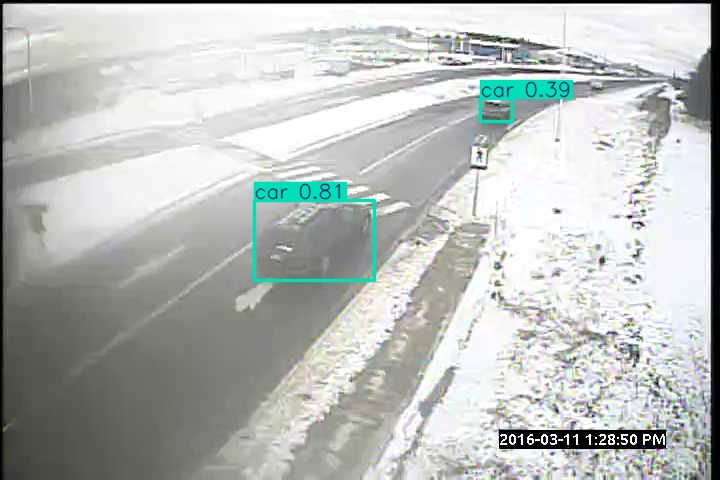

In [12]:
from IPython.display import Image, display
import os

pred_dir = "../notebooks/runs/outputs/predictions/test_predictions"
sample_file = os.listdir(pred_dir)[0]

print("Showing:", sample_file)
display(Image(filename=os.path.join(pred_dir, sample_file)))

In [13]:
import pandas as pd

df2 = pd.read_csv("../data/Tesla - Deaths.csv")

print(df2.head())
print("\nShape:", df2.shape)
print("\nColumns:")
print(df2.columns.tolist())

   Case #    Year        Date  Country   State   \
0   294.0  2022.0   1/17/2023      USA       CA   
1   293.0  2022.0    1/7/2023   Canada        -   
2   292.0  2022.0    1/7/2023      USA       WA   
3   291.0  2022.0  12/22/2022      USA       GA   
4   290.0  2022.0  12/19/2022   Canada        -   

                         Description    Deaths   Tesla driver   \
0    Tesla crashes into back of semi        1.0             1    
1                      Tesla crashes        1.0             1    
2   Tesla hits pole, catches on fire        1.0             -    
3            Tesla crashes and burns        1.0             1    
4      Tesla crashes into storefront        1.0             -    

   Tesla occupant   Other vehicle   ...  Verified Tesla Autopilot Deaths   \
0               -               -   ...                                -    
1               -               -   ...                                -    
2               1               -   ...                          

In [14]:
import os

path = "../outputs/model/vehicle_detector"

print("Exists:", os.path.exists(path))
print("Files:", os.listdir(path))

Exists: False


FileNotFoundError: [WinError 3] The system cannot find the path specified: '../outputs/model/vehicle_detector'

In [15]:
import os

for root, dirs, files in os.walk("../"):
    if "vehicle_detector" in root:
        print("FOUND:", root)
        print("Files:", files)

FOUND: ../notebooks\runs\outputs\model\vehicle_detector
Files: ['args.yaml', 'labels.jpg', 'results.csv', 'train_batch0.jpg', 'train_batch1.jpg', 'train_batch2.jpg']
FOUND: ../notebooks\runs\outputs\model\vehicle_detector\weights
Files: ['best.pt', 'last.pt']
